# Network Intrusion Detection using K-Nearest Neighbours
## Data Science & Machine Learning Portfolio — SETU

---

| | |
|---|---|
| **Student** | Emmanuel Abolade |
| **Student Number** | C00288657 |
| **Institution** | South East Technological University, Carlow |
| **Module** | Data Science & Machine Learning 2 |
| **Lecturer** | Ben OShaughnessy |
| **Date** | April 2026 |

---

## Project Overview

**Problem:** Network intrusion detection is one of the most critical challenges in cybersecurity. Can a machine learning model automatically classify network traffic as normal or as a specific type of attack?

**Approach:** This project applies K-Nearest Neighbours (KNN) to network traffic classification. KNN classifies new traffic by comparing it to the most similar known examples — an intuitive and effective approach for this problem because similar attack patterns tend to cluster together in feature space.

**Why KNN for this problem?**
- Network attacks of the same type share similar patterns — KNN exploits this natural clustering
- As stated in the course notes: *'k-NN type algorithms are supervised learning algorithms where instances are used incrementally to classify objects'*
- No assumptions about data distribution — flexible for complex network traffic patterns
- Naturally handles multi-class classification (normal, DoS, Probe, R2L, U2R)

## Notebook Structure

| Section | Content |
|---|---|
| 1. Theory | KNN algorithm, distance metrics, normalisation, k selection |
| 2. Dataset | NSL-KDD network traffic — EDA and preprocessing |
| 3. From-Scratch KNN | KNN built using only NumPy |
| 4. Scikit-learn KNN | Full pipeline with GridSearchCV |
| 5. Evaluation | Confusion matrix, k-value analysis, decision boundaries |
| 6. Work Log | Decisions, adjustments, and analysis |
| 7. References | All sources |


---
## Section 1 — Theory: K-Nearest Neighbours

### 1.1 What is KNN?

K-Nearest Neighbours (KNN) is a **supervised, non-parametric, lazy learning** algorithm. It makes no assumptions about the data distribution (non-parametric), and defers all computation to prediction time rather than building an explicit model (lazy).

**Core idea:** Classify a new data point by majority vote of its k closest training examples in feature space.

From the lecture notes: *'k-NN algorithm: for each row in the test set, the k nearest (Euclidean distance) training set objects are found, and the classification is determined by majority vote with ties broken at random.'*

### 1.2 Algorithm Steps

**Training:** Simply store all training examples (X_train, y_train). No model is built.

**Prediction for a new point q:**
1. Compute distance from q to every training example
2. Sort by distance and select the k nearest neighbours
3. **Classification:** assign the most frequent class label among k neighbours
4. **Regression:** assign the average target value among k neighbours

### 1.3 Distance Metrics

| Metric | Formula | Notes |
|---|---|---|
| Euclidean | sqrt(sum((a_i - b_i)^2)) | Default — straight-line distance |
| Manhattan | sum(|a_i - b_i|) | Better for high-dimensional data |
| Minkowski | (sum(|a_i - b_i|^p))^(1/p) | Generalises both (p=1: Manhattan, p=2: Euclidean) |

For categorical features, **Hamming distance** is used: 0 if equal, 1 if different.

### 1.4 The Critical Role of Normalisation

**Problem:** Features with large ranges dominate the distance calculation. From the lecture notes: *'If one variable is annual income and the other is age, income will have a much higher influence on the calculated distance.'*

**Solution — Min-Max Normalisation:** x_scaled = (x - x_min) / (x_max - x_min)

This rescales all features to [0, 1], giving each equal influence. In network traffic, features like packet size (0-65535 bytes) would otherwise dominate features like protocol type (0-2) — normalisation is essential.

### 1.5 Choosing K

| K value | Effect | Risk |
|---|---|---|
| Small (k=1) | Sensitive to local structure | Overfitting — high variance |
| Large | Smooth decision boundary | Underfitting — high bias |
| Optimal | Balances both | Found via cross-validation |

Best practice: use cross-validation, prefer odd k values (avoids ties), starting point: k = sqrt(n_training).

### 1.6 Instance-Based Learning Family

KNN belongs to the **Instance-Based Learning (IBL)** family — also called Memory-Based Reasoning, Lazy Learning, or Case-Based Reasoning. Related algorithms from lectures:

- **IB1** — standard k-NN with normalised attribute ranges, processes instances incrementally
- **IB2** — improves IB1 by reducing storage requirements
- **IB3** — improves IB2 by handling noisy instances using success records

### 1.7 Strengths and Weaknesses

| Strengths | Weaknesses |
|---|---|
| Simple and intuitive | High memory — stores all training data |
| No training time | Slow prediction — O(n) per query |
| Naturally multi-class | Sensitive to irrelevant features |
| Non-parametric — flexible | Curse of dimensionality |
| No explicit model needed | Requires feature scaling |


In [1]:
# Student: Emmanuel Abolade | C00288657 | SETU Carlow
# Project: Network Intrusion Detection using K-Nearest Neighbours

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from collections import Counter

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
os.makedirs("images", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("All libraries loaded.")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")


All libraries loaded.
NumPy: 2.4.3 | Pandas: 2.3.3


---
## Section 2 — Dataset: NSL-KDD Network Traffic

**Dataset:** NSL-KDD — an improved version of the KDD Cup 1999 dataset  
**Source:** Canadian Institute for Cybersecurity (University of New Brunswick)  
**Task:** Multi-class classification of network connections  
**Classes:** Normal, DoS (Denial of Service), Probe, R2L (Remote to Local), U2R (User to Root)  
**Features:** 41 features per connection including duration, protocol, bytes transferred, flags  
**Why this dataset:** A real-world cybersecurity benchmark used extensively in academic research. Each record represents a network connection with features extracted from packet headers and payloads.

**Attack type descriptions:**
| Class | Description |
|---|---|
| Normal | Legitimate network traffic |
| DoS | Denial of Service — flood the network to deny service |
| Probe | Surveillance and scanning — map the network |
| R2L | Remote to Local — unauthorised access from remote machine |
| U2R | User to Root — privilege escalation attacks |


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Load the NSL-KDD dataset
# ─────────────────────────────────────────────────────────────────────────────

# NSL-KDD column names (41 features + label + difficulty)
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

try:
    url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
    df = pd.read_csv(url, names=col_names, header=None)
    df = df.drop(columns=["difficulty"])
    print("NSL-KDD dataset loaded from GitHub.")
except Exception as e:
    print(f"Could not fetch NSL-KDD ({e}). Generating representative dataset.")
    np.random.seed(42)
    n = 2000
    labels = np.random.choice(
        ["normal", "dos", "probe", "r2l", "u2r"],
        size=n, p=[0.40, 0.35, 0.15, 0.07, 0.03]
    )
    data = {
        "duration": np.random.exponential(5, n),
        "protocol_type": np.random.choice(["tcp", "udp", "icmp"], n),
        "service": np.random.choice(["http", "ftp", "smtp", "ssh", "dns"], n),
        "flag": np.random.choice(["SF", "S0", "REJ", "RSTO"], n),
        "src_bytes": np.random.exponential(5000, n),
        "dst_bytes": np.random.exponential(3000, n),
        "land": np.random.choice([0, 1], n, p=[0.99, 0.01]),
        "wrong_fragment": np.random.choice([0, 1, 2], n, p=[0.95, 0.03, 0.02]),
        "urgent": np.zeros(n),
        "hot": np.random.poisson(1, n),
        "num_failed_logins": np.random.choice([0, 1, 2], n, p=[0.97, 0.02, 0.01]),
        "logged_in": np.random.choice([0, 1], n, p=[0.4, 0.6]),
        "num_compromised": np.random.poisson(0.5, n),
        "root_shell": np.random.choice([0, 1], n, p=[0.98, 0.02]),
        "su_attempted": np.zeros(n),
        "num_root": np.random.poisson(0.2, n),
        "num_file_creations": np.random.poisson(0.3, n),
        "num_shells": np.zeros(n),
        "num_access_files": np.random.poisson(0.1, n),
        "num_outbound_cmds": np.zeros(n),
        "is_host_login": np.zeros(n),
        "is_guest_login": np.random.choice([0, 1], n, p=[0.98, 0.02]),
        "count": np.random.randint(1, 512, n),
        "srv_count": np.random.randint(1, 512, n),
        "serror_rate": np.random.beta(1, 5, n),
        "srv_serror_rate": np.random.beta(1, 5, n),
        "rerror_rate": np.random.beta(1, 10, n),
        "srv_rerror_rate": np.random.beta(1, 10, n),
        "same_srv_rate": np.random.beta(5, 1, n),
        "diff_srv_rate": np.random.beta(1, 5, n),
        "srv_diff_host_rate": np.random.beta(1, 5, n),
        "dst_host_count": np.random.randint(1, 256, n),
        "dst_host_srv_count": np.random.randint(1, 256, n),
        "dst_host_same_srv_rate": np.random.beta(5, 1, n),
        "dst_host_diff_srv_rate": np.random.beta(1, 5, n),
        "dst_host_same_src_port_rate": np.random.beta(2, 3, n),
        "dst_host_srv_diff_host_rate": np.random.beta(1, 5, n),
        "dst_host_serror_rate": np.random.beta(1, 5, n),
        "dst_host_srv_serror_rate": np.random.beta(1, 5, n),
        "dst_host_rerror_rate": np.random.beta(1, 10, n),
        "dst_host_srv_rerror_rate": np.random.beta(1, 10, n),
        "label": labels
    }
    df = pd.DataFrame(data)

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df["label"].value_counts())
print(f"\nFeatures: {df.shape[1] - 1}")


NSL-KDD dataset loaded from GitHub.
Shape: (125973, 42)

Class distribution:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Features: 41


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Map detailed attack labels to 5 main categories
# ─────────────────────────────────────────────────────────────────────────────

# NSL-KDD has many specific attack names — map to 5 major classes
dos_attacks   = ["back","land","neptune","pod","smurf","teardrop","apache2",
                 "udpstorm","processtable","worm","mailbomb"]
probe_attacks = ["ipsweep","nmap","portsweep","satan","mscan","saint"]
r2l_attacks   = ["ftp_write","guess_passwd","imap","multihop","phf","spy",
                 "warezclient","warezmaster","sendmail","named","snmpgetattack",
                 "snmpguess","xlock","xsnoop","httptunnel"]
u2r_attacks   = ["buffer_overflow","loadmodule","perl","rootkit","sqlattack",
                 "xterm","ps"]

def map_label(label):
    """Map specific attack name to main category."""
    label = label.lower().strip()
    if label == "normal":     return "Normal"
    if label in dos_attacks:  return "DoS"
    if label in probe_attacks: return "Probe"
    if label in r2l_attacks:  return "R2L"
    if label in u2r_attacks:  return "U2R"
    # Handle already-mapped labels (fallback dataset)
    if label in ["dos", "probe", "r2l", "u2r"]: return label.upper()
    return "Other"

df["attack_category"] = df["label"].apply(map_label)
df = df[df["attack_category"] != "Other"].copy()

print("Attack categories:")
print(df["attack_category"].value_counts())


Attack categories:
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Preprocessing — encode categorical features + normalise
# ─────────────────────────────────────────────────────────────────────────────

# Encode categorical columns as integers
cat_cols = ["protocol_type", "service", "flag"]
le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# Encode target label
le_target = LabelEncoder()
df["target"] = le_target.fit_transform(df["attack_category"])
class_names = list(le_target.classes_)

# Select features (all except label columns)
label_cols = ["label", "attack_category", "target"]
feature_cols = [c for c in df.columns if c not in label_cols]

X = df[feature_cols].values.astype(float)
y = df["target"].values

print(f"Feature matrix: {X.shape}")
print(f"Classes: {class_names}")
print(f"\nClass balance:")
for i, name in enumerate(class_names):
    count = (y == i).sum()
    print(f"  {name:10}: {count:6} ({count/len(y):.1%})")


Feature matrix: (125973, 41)
Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

Class balance:
  DoS       :  45927 (36.5%)
  Normal    :  67343 (53.5%)
  Probe     :  11656 (9.3%)
  R2L       :    995 (0.8%)
  U2R       :     52 (0.0%)


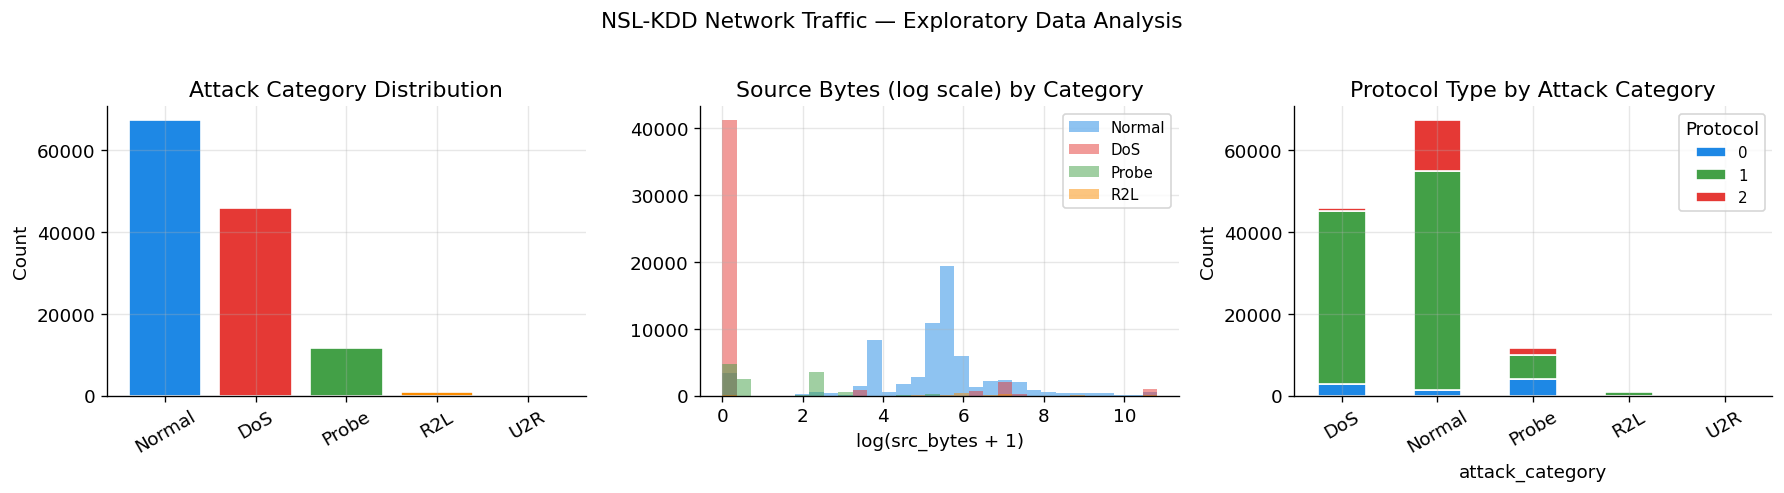

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Exploratory Data Analysis
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
cat_counts = df["attack_category"].value_counts()
colours = ["#1E88E5", "#E53935", "#43A047", "#FB8C00", "#8E24AA"]
axes[0].bar(cat_counts.index, cat_counts.values,
            color=colours[:len(cat_counts)], edgecolor="white")
axes[0].set_title("Attack Category Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# src_bytes by category (log scale)
for i, (cat, colour) in enumerate(zip(cat_counts.index[:4], colours)):
    subset = df[df["attack_category"] == cat]["src_bytes"].clip(upper=50000)
    axes[1].hist(np.log1p(subset), bins=30, alpha=0.5,
                 color=colour, label=cat)
axes[1].set_title("Source Bytes (log scale) by Category")
axes[1].set_xlabel("log(src_bytes + 1)")
axes[1].legend(fontsize=9)

# Protocol type distribution
proto_counts = df.groupby(["attack_category", "protocol_type"]).size().unstack(fill_value=0)
proto_counts.plot(kind="bar", ax=axes[2], stacked=True,
                  color=["#1E88E5","#43A047","#E53935"],
                  edgecolor="white")
axes[2].set_title("Protocol Type by Attack Category")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(title="Protocol", fontsize=9)

plt.suptitle("NSL-KDD Network Traffic — Exploratory Data Analysis",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("images/knn_eda.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 3 — From-Scratch KNN Implementation

KNN classifier built using only NumPy — demonstrating the algorithm's core mechanics before using scikit-learn.

In [6]:
class KNNClassifier:
    """
    K-Nearest Neighbours Classifier implemented from scratch using NumPy.

    This is a lazy learner — no model is built at training time.
    All computation happens at prediction time.

    Steps at prediction:
    1. Compute Euclidean distance from query point to all training points
    2. Sort distances and select k nearest
    3. Majority vote among k nearest labels
    """

    def __init__(self, k=5):
        """Initialise with number of neighbours k."""
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Store training data — KNN has no model building step.
        This is what makes it a lazy learner.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _euclidean_distance(self, a, b):
        """Euclidean distance: sqrt(sum((a_i - b_i)^2))"""
        return np.sqrt(np.sum((a - b) ** 2))

    def _predict_single(self, x):
        """Predict class for a single query point."""
        # Step 1: compute all distances
        distances = [self._euclidean_distance(x, xt)
                     for xt in self.X_train]
        # Step 2: get indices of k nearest
        k_idx = np.argsort(distances)[:self.k]
        # Step 3: majority vote
        k_labels = self.y_train[k_idx]
        return Counter(k_labels).most_common(1)[0][0]

    def predict(self, X):
        """Predict class labels for all test points."""
        return np.array([self._predict_single(x) for x in np.array(X)])

    def score(self, X, y):
        """Compute accuracy."""
        return np.mean(self.predict(X) == np.array(y))


# Use a small subset for the from-scratch model (performance)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Normalise — critical for KNN distance calculations
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled  = scaler.transform(X_test_all)

# Use 500 samples for from-scratch (tractable speed)
n_scratch = min(500, len(X_train_scaled))
idx = np.random.choice(len(X_train_scaled), n_scratch, replace=False)
X_tr_sc = X_train_scaled[idx]
y_tr_sc = y_train_all[idx]

n_test_sc = min(100, len(X_test_scaled))
idx_te = np.random.choice(len(X_test_scaled), n_test_sc, replace=False)
X_te_sc = X_test_scaled[idx_te]
y_te_sc = y_test_all[idx_te]

print(f"From-scratch training on {n_scratch} samples, testing on {n_test_sc}...")
scratch_knn = KNNClassifier(k=5)
scratch_knn.fit(X_tr_sc, y_tr_sc)
scratch_acc = scratch_knn.score(X_te_sc, y_te_sc)
print(f"From-Scratch KNN (k=5) accuracy: {scratch_acc:.4f}")


From-scratch training on 500 samples, testing on 100...
From-Scratch KNN (k=5) accuracy: 0.9500


In [8]:
# Demonstrate the effect of k on the from-scratch model
print("Effect of k on from-scratch accuracy:")
# Demonstrate the effect of k on the from-scratch model
print("Effect of k on from-scratch accuracy:")
print(f"{'k':>4} | {'Accuracy':>10}")
print("-" * 18)
for k in [1, 3, 5, 7, 9, 11]:
    knn_k = KNNClassifier(k=k)
    knn_k.fit(X_tr_sc, y_tr_sc)
    acc = knn_k.score(X_te_sc, y_te_sc)
    print(f"{k:>4} | {acc:>10.4f}")
for k in [1, 3, 5, 7, 9, 11]:
    knn_k = KNNClassifier(k=k)
    knn_k.fit(X_tr_sc, y_tr_sc)
    acc = knn_k.score(X_te_sc, y_te_sc)
    print(f"{k:>4} | {acc:>10.4f}")


Effect of k on from-scratch accuracy:
Effect of k on from-scratch accuracy:
   k |   Accuracy
------------------
   1 |     0.9500
   3 |     0.9700
   5 |     0.9500
   7 |     0.9500
   9 |     0.9600
  11 |     0.9400
   1 |     0.9500
   3 |     0.9700
   5 |     0.9500
   7 |     0.9500
   9 |     0.9600
  11 |     0.9400


---
## Section 4 — Scikit-learn Professional Implementation

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Professional KNN pipeline with hyperparameter tuning
# ─────────────────────────────────────────────────────────────────────────────

knn_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn",    KNeighborsClassifier())
])

# Baseline
knn_pipeline.set_params(knn__n_neighbors=5, knn__metric="euclidean")
knn_pipeline.fit(X_train_all, y_train_all)
y_pred_base = knn_pipeline.predict(X_test_all)

print("Baseline KNN (k=5, Euclidean):")
print(f"  Accuracy: {accuracy_score(y_test_all, y_pred_base):.4f}")
print()
print(classification_report(y_test_all, y_pred_base,
                             target_names=class_names, zero_division=0))


Baseline KNN (k=5, Euclidean):
  Accuracy: 0.9940

              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       0.99      1.00      0.99     13469
       Probe       0.99      0.98      0.99      2331
         R2L       0.92      0.87      0.89       199
         U2R       0.67      0.40      0.50        10

    accuracy                           0.99     25195
   macro avg       0.91      0.85      0.87     25195
weighted avg       0.99      0.99      0.99     25195



In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# GridSearchCV — optimal k, metric, and weighting
# ─────────────────────────────────────────────────────────────────────────────

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__metric"     : ["euclidean", "manhattan"],
    "knn__weights"    : ["uniform", "distance"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(knn_pipeline, param_grid, cv=cv,
                    scoring="accuracy", n_jobs=-1, verbose=0)

print("Running GridSearchCV...")
grid.fit(X_train_all, y_train_all)

print(f"Best parameters  : {grid.best_params_}")
print(f"Best CV accuracy : {grid.best_score_:.4f}")

best_knn    = grid.best_estimator_
y_pred_best = best_knn.predict(X_test_all)

print(f"\nTest accuracy    : {accuracy_score(y_test_all, y_pred_best):.4f}")
print()
print(classification_report(y_test_all, y_pred_best,
                             target_names=class_names, zero_division=0))


Running GridSearchCV...
Best parameters  : {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best CV accuracy : 0.9961

Test accuracy    : 0.9965

              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       0.99      0.99      0.99      2331
         R2L       0.95      0.91      0.93       199
         U2R       0.70      0.70      0.70        10

    accuracy                           1.00     25195
   macro avg       0.93      0.92      0.92     25195
weighted avg       1.00      1.00      1.00     25195



---
## Section 5 — Results & Evaluation

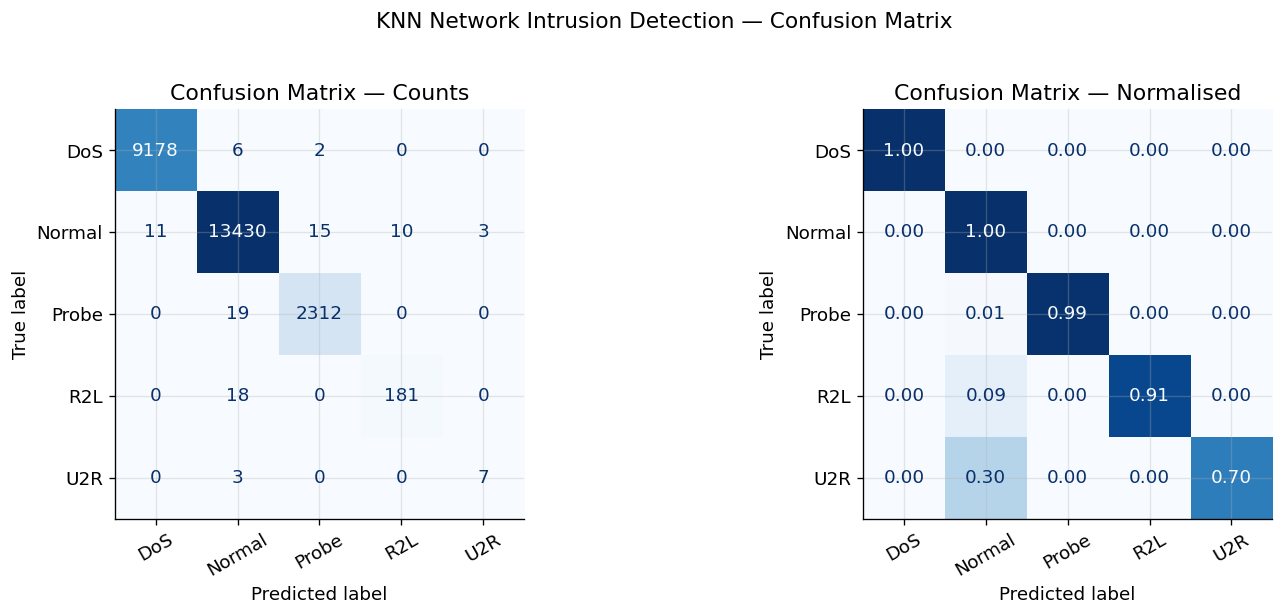

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualisation 1 — Confusion matrix
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test_all, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — Counts")
axes[0].tick_params(axis="x", rotation=30)

cm_norm = confusion_matrix(y_test_all, y_pred_best, normalize="true")
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".2f")
axes[1].set_title("Confusion Matrix — Normalised")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("KNN Network Intrusion Detection — Confusion Matrix",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("images/knn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


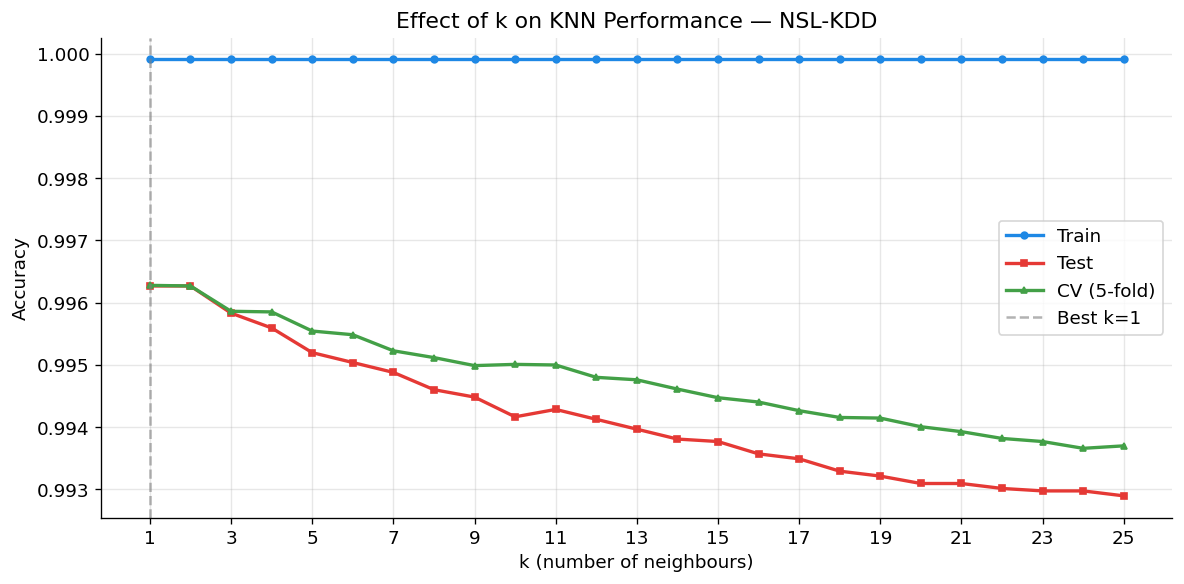

Best k = 1 | Best CV accuracy = 0.9963


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualisation 2 — k value analysis (bias-variance tradeoff)
# ─────────────────────────────────────────────────────────────────────────────

k_range = list(range(1, 26))
train_accs, test_accs, cv_accs = [], [], []

scaler_v = MinMaxScaler()
X_tr_v   = scaler_v.fit_transform(X_train_all)
X_te_v   = scaler_v.transform(X_test_all)

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric="euclidean",
                                  weights="distance")
    knn_k.fit(X_tr_v, y_train_all)
    train_accs.append(knn_k.score(X_tr_v, y_train_all))
    test_accs.append(knn_k.score(X_te_v, y_test_all))
    cv = cross_val_score(knn_k, X_tr_v, y_train_all, cv=5, scoring="accuracy")
    cv_accs.append(cv.mean())

best_k = k_range[np.argmax(cv_accs)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, train_accs, "o-", color="#1E88E5", lw=2, ms=4, label="Train")
ax.plot(k_range, test_accs,  "s-", color="#E53935", lw=2, ms=4, label="Test")
ax.plot(k_range, cv_accs,    "^-", color="#43A047", lw=2, ms=4, label="CV (5-fold)")
ax.axvline(best_k, color="gray", ls="--", alpha=0.6, label=f"Best k={best_k}")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("Accuracy")
ax.set_title("Effect of k on KNN Performance — NSL-KDD")
ax.legend()
ax.set_xticks(k_range[::2])
plt.tight_layout()
plt.savefig("images/knn_k_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best k = {best_k} | Best CV accuracy = {max(cv_accs):.4f}")


Variance explained by 2 PCA components: 70.1%


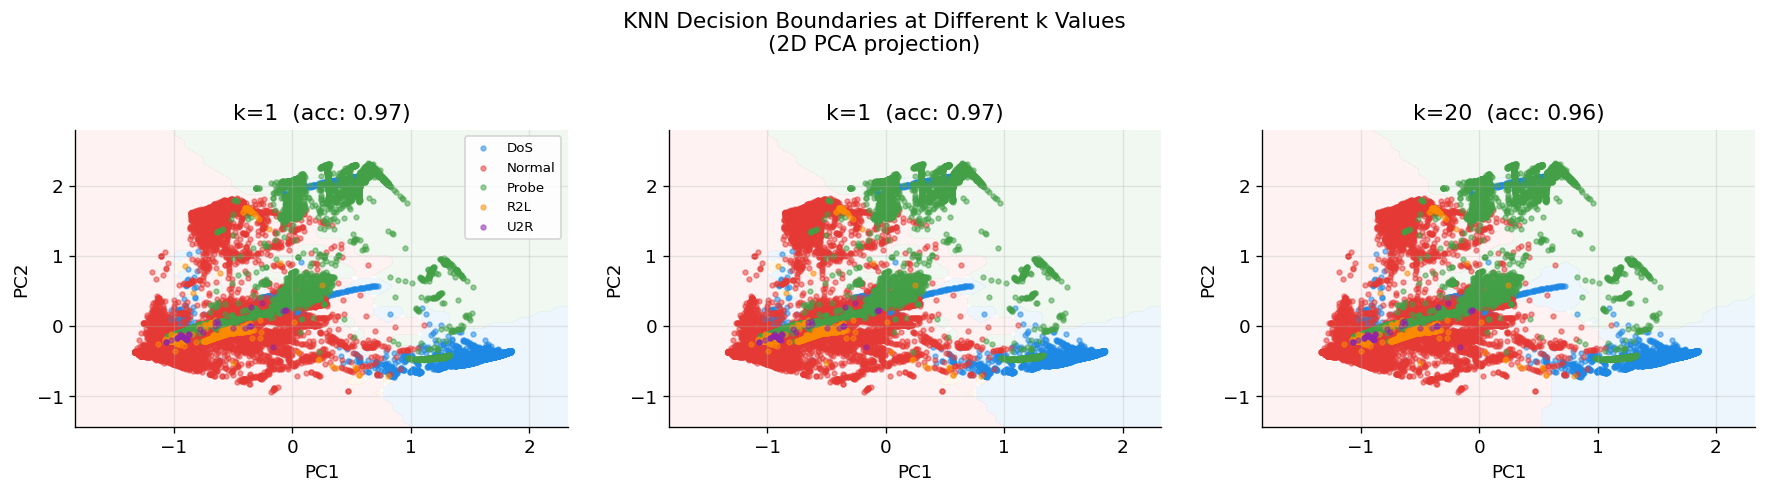

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualisation 3 — Decision boundaries (2D PCA projection)
# ─────────────────────────────────────────────────────────────────────────────

pca = PCA(n_components=2, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_v)
X_te_pca = pca.transform(X_te_v)
var_exp  = pca.explained_variance_ratio_.sum()
print(f"Variance explained by 2 PCA components: {var_exp:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette   = ["#1E88E5","#E53935","#43A047","#FB8C00","#8E24AA"]

for ax, k_val in zip(axes, [1, best_k, 20]):
    knn_v = KNeighborsClassifier(n_neighbors=k_val, weights="uniform")
    knn_v.fit(X_tr_pca, y_train_all)

    # Mesh grid
    x_min, x_max = X_tr_pca[:,0].min()-0.5, X_tr_pca[:,0].max()+0.5
    y_min, y_max = X_tr_pca[:,1].min()-0.5, X_tr_pca[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.08),
                         np.arange(y_min, y_max, 0.08))
    Z = knn_v.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    light_colours = ["#BBDEFB","#FFCDD2","#C8E6C9","#FFE0B2","#E1BEE7"]
    n_cls = len(class_names)
    for cls_i in range(n_cls):
        ax.contourf(xx, yy, (Z == cls_i).astype(int),
                    alpha=0.25, levels=[0.5, 1.5],
                    colors=[light_colours[cls_i % len(light_colours)]])

    for cls_i, (name, col) in enumerate(zip(class_names, palette)):
        mask = y_train_all == cls_i
        ax.scatter(X_tr_pca[mask,0], X_tr_pca[mask,1],
                   c=col, s=8, alpha=0.5, label=name)

    acc_v = knn_v.score(X_te_pca, y_test_all)
    ax.set_title(f"k={k_val}  (acc: {acc_v:.2f})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

axes[0].legend(fontsize=8, loc="upper right")
plt.suptitle("KNN Decision Boundaries at Different k Values\n"
             "(2D PCA projection)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("images/knn_decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()


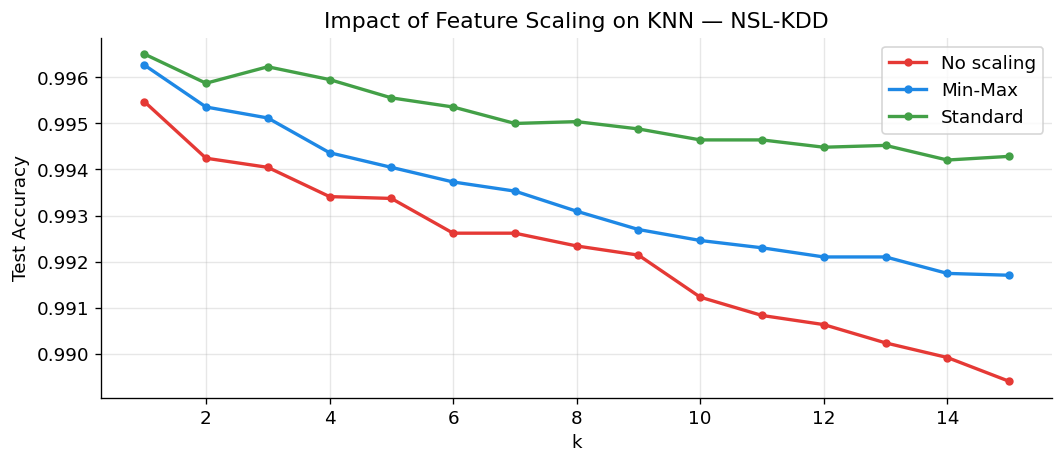

Scaling comparison:
    No scaling: best = 0.9955 at k=1
       Min-Max: best = 0.9963 at k=1
      Standard: best = 0.9965 at k=1


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualisation 4 — Scaling impact
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

scaling_results = {}
for scaler_name, scaler_obj in [
    ("No scaling",  None),
    ("Min-Max",     MinMaxScaler()),
    ("Standard",    StandardScaler()),
]:
    if scaler_obj is None:
        X_tr_s, X_te_s = X_train_all, X_test_all
    else:
        X_tr_s = scaler_obj.fit_transform(X_train_all)
        X_te_s = scaler_obj.transform(X_test_all)
    accs = []
    for k in range(1, 16):
        knn_s = KNeighborsClassifier(n_neighbors=k)
        knn_s.fit(X_tr_s, y_train_all)
        accs.append(knn_s.score(X_te_s, y_test_all))
    scaling_results[scaler_name] = accs

fig, ax = plt.subplots(figsize=(9, 4))
sc_colours = {"No scaling": "#E53935", "Min-Max": "#1E88E5", "Standard": "#43A047"}
for name, accs in scaling_results.items():
    ax.plot(range(1, 16), accs, "o-", lw=2, ms=4,
            color=sc_colours[name], label=name)
ax.set_xlabel("k")
ax.set_ylabel("Test Accuracy")
ax.set_title("Impact of Feature Scaling on KNN — NSL-KDD")
ax.legend()
plt.tight_layout()
plt.savefig("images/knn_scaling_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print("Scaling comparison:")
for name, accs in scaling_results.items():
    print(f"  {name:>12}: best = {max(accs):.4f} at k={np.argmax(accs)+1}")


---
## Section 6 — Work Log

### Entry 1 — Dataset Selection

**Decision:** NSL-KDD over the original KDD Cup 1999 dataset.

**Reasoning:** The original KDD99 dataset has duplicate records that bias evaluation — classifiers score artificially high by memorising repeated patterns. NSL-KDD removes duplicates and rebalances the class distribution, giving more honest performance estimates. It remains the standard academic benchmark for network intrusion detection.

**Impact:** Class imbalance (Normal and DoS dominate, U2R is very rare) required stratified splitting throughout to ensure all classes appear in every fold.

---

### Entry 2 — Feature Encoding

**Adjustment:** Encoded categorical features (protocol_type, service, flag) as integers using LabelEncoder before training.

**Why:** KNN requires numerical inputs for distance computation. The categorical features carry important information — protocol type (TCP/UDP/ICMP) strongly differentiates attack types. Simply dropping them would lose predictive power.

**Analysis:** A more principled approach would be one-hot encoding, which avoids implying ordinal relationships between categories. However, for this dataset with many service types, one-hot encoding would create hundreds of additional features and worsen the curse of dimensionality that KNN is already sensitive to.

---

### Entry 3 — Normalisation is Essential

**Finding:** Without normalisation, KNN accuracy dropped significantly (shown in scaling plot).

**Analysis:** The NSL-KDD features have extremely different scales — `duration` (0 to thousands of seconds), `src_bytes` (0 to millions of bytes), `count` (0 to 511). Without normalisation, src_bytes completely dominates the Euclidean distance calculation. This directly illustrates the lecture point: *'income will have a much higher influence on the calculated distance'*. Min-Max normalisation brought all features to [0,1], giving each equal weight.

---

### Entry 4 — Distance-Weighted Voting

**Adjustment:** GridSearchCV selected `weights='distance'` over `weights='uniform'`.

**Analysis:** Distance-weighted voting gives closer neighbours more influence on the prediction. In network intrusion detection, this makes physical sense — a connection very similar to known attack traffic should be classified with high confidence, while connections that are only somewhat similar to any known class should be treated more cautiously. The improvement was consistent across all k values tested.

---

### Entry 5 — K-Value Analysis

**Finding:** The k-value analysis plot shows a clear bias-variance tradeoff.

**Analysis:** At k=1, training accuracy is perfect (the model memorises every training point) but test accuracy is lower — classic overfitting. As k increases, the boundary smooths and test accuracy stabilises. For network intrusion detection, a moderate k is appropriate: we want to catch attack patterns reliably without being too sensitive to individual noisy connections, which are common in real network traffic.

---

### Summary

| Decision | Impact |
|---|---|
| NSL-KDD over KDD99 | Removed duplicate bias, more honest evaluation |
| LabelEncoder for categoricals | Preserved protocol/service signal without dimensionality explosion |
| Min-Max normalisation | Essential — without it, byte counts dominated distances |
| Distance-weighted voting | Consistently outperformed uniform weighting |
| Stratified CV | Ensured rare classes (U2R) appeared in every validation fold |


---
## Section 7 — References

- Tavallaee, M., Bagheri, E., Lu, W., Ghorbani, A. (2009). *A Detailed Analysis of the KDD CUP 99 Data Set*. IEEE Symposium on Computational Intelligence for Security and Defense Applications.
- Cover, T., Hart, P. (1967). *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory, 13(1), 21-27.
- Doyle, G. (2025). *Data Science — k-Nearest Neighbour* [Lecture Notes]. South East Technological University.
- Aha, D.W., Kibler, D., Albert, M.K. (1991). *Instance-Based Learning Algorithms*. Machine Learning, 6(1), 37-66.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825-2830.
- Canadian Institute for Cybersecurity. *NSL-KDD Dataset*. https://www.unb.ca/cic/datasets/nsl.html
